# Three Generations Seeking Romance - Regression & Classification

#### Predicting individuals' ages and classifying their generational group by analyzing user profiles.

##  Data Dictionary

- **age**: Kullanıcının yaşı  
- **body_type**: Vücut tipi (örneğin: *athletic*, *average*, *thin*)  
- **diet**: Beslenme tercihi (örneğin: *vegetarian*, *anything*, *vegan*)  
- **drinks**: Alkol kullanma durumu ve sıklığı  
- **drugs**: Uyuşturucu kullanımı (örneğin: *never*, *sometimes*)  
- **education**: Eğitim seviyesi ve durumu (örneğin: *graduated from college*)  
- **essay0 - essay9**: Kullanıcının kendini tanıttığı 10 serbest yazı alanı  
- **ethnicity**: Etnik köken bilgisi  
- **height**: Kullanıcının boyu (inç cinsinden)  
- **income**: Yıllık gelir düzeyi  
- **job**: Meslek bilgisi  
- **last_online**: Son çevrim içi olma zamanı  
- **location**: Yaşanılan şehir ve eyalet bilgisi  
- **offspring**: Çocuk durumu (var mı, ister mi vs.)  
- **orientation**: Cinsel yönelim (örneğin: *straight*, *gay*, *bisexual*)  
- **pets**: Evcil hayvan tercihi (örneğin: *likes cats*, *has dogs*)  
- **religion**: Dini inanç ve bu inanca verilen önem  
- **sex**: Cinsiyet (*m* = erkek, *f* = kadın)  
- **sign**: Burç ve burçlara verilen önem  
- **smokes**: Sigara içme durumu  
- **speaks**: Konuşulan diller ve seviyeleri  
- **status**: İlişki durumu (örneğin: *single*, *available*)  


<img src="img.png" width="600" height="100">

### Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", 100)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

### Import Data

In [7]:
df = pd.read_csv("profiles.csv")

### Exploratory Data Analysis - Data Imputation - Feature Engineering

In [9]:
df.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9,ethnicity,height,income,job,last_online,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22.00,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...","books:<br />\nabsurdistan, the republic, of mi...",food.<br />\nwater.<br />\ncell phone.<br />\n...,duality and humorous things,trying to find someone to hang out with. i am ...,i am new to california and looking for someone...,you want to be swept off your feet!<br />\nyou...,"asian, white",75.00,-1.00,transportation,2012-06-28-20-30,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35.00,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,i am die hard christopher moore fan. i don't r...,delicious porkness in all of its glories.<br /...,NaN,NaN,i am very open and will share just about anyth...,NaN,white,70.00,80000.00,hospitality / travel,2012-06-29-21-41,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38.00,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,okay this is where the cultural matrix gets so...,movement<br />\nconversation<br />\ncreation<b...,NaN,viewing. listening. dancing. talking. drinking...,"when i was five years old, i was known as ""the...","you are bright, open, intense, silly, ironic, ...",NaN,68.00,-1.00,NaN,2012-06-27-09-10,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23.00,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,"bataille, celine, beckett. . .<br />\nlynch, j...",NaN,cats and german philosophy,NaN,NaN,you feel so inclined.,white,71.00,20000.00,student,2012-06-28-14-22,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29.00,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,"music: bands, rappers, musicians<br />\nat the...",NaN,NaN,NaN,NaN,NaN,"asian, black, other",66.00,-1.00,artistic / musical / writer,2012-06-27-21-26,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60552 entries, 0 to 60551
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          9514 non-null   float64
 1   body_type    8666 non-null   object 
 2   diet         5761 non-null   object 
 3   drinks       9012 non-null   object 
 4   drugs        7215 non-null   object 
 5   education    8459 non-null   object 
 6   essay0       8667 non-null   object 
 7   essay1       8347 non-null   object 
 8   essay2       8049 non-null   object 
 9   essay3       7690 non-null   object 
 10  essay4       7879 non-null   object 
 11  essay5       7814 non-null   object 
 12  essay6       7352 non-null   object 
 13  essay7       7553 non-null   object 
 14  essay8       6361 non-null   object 
 15  essay9       7554 non-null   object 
 16  ethnicity    8565 non-null   object 
 17  height       9514 non-null   float64
 18  income       9514 non-null   float64
 19  job 

In [11]:
df.shape

(60552, 31)

In [12]:
df.describe()

,age,height,income
count,9514.00,9514.00,9514.00
mean,32.08,68.34,18887.15
std,9.45,3.91,91428.81
min,18.00,36.00,-1.00
25%,25.00,66.00,-1.00
50%,30.00,68.00,-1.00
75%,36.00,71.00,-1.00
max,110.00,95.00,1000000.00


In [13]:
df.isnull().sum()

age            51038
body_type      51886
diet           54791
drinks         51540
drugs          53337
education      52093
essay0         51885
essay1         52205
essay2         52503
essay3         52862
essay4         52673
essay5         52738
essay6         53200
essay7         52999
essay8         54191
essay9         52998
ethnicity      51987
height         51038
income         51038
job            52369
last_online    51038
location       51038
offspring      56666
orientation    51038
pets           54200
religion       54291
sex            51038
sign           52776
smokes         51956
speaks         51044
status         51038
dtype: int64

In [14]:
df.tail(12)

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9,ethnicity,height,income,job,last_online,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
60540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60544,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60548,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df.drop_duplicates(inplace=True)
#tekrarlanan satırları verimizden kaldırdık

In [16]:
#Çok fazla eksik değer içeren satırları siliyoruz
threshold_row = len(df.columns) * .6
df = df.dropna(thresh=threshold_row)

In [17]:
df.isnull().sum()

age               0
body_type       739
diet           3409
drinks          349
drugs          2125
education       833
essay0          588
essay1          814
essay2         1063
essay3         1405
essay4         1225
essay5         1288
essay6         1722
essay7         1527
essay8         2700
essay9         1551
ethnicity       797
height            0
income            0
job            1060
last_online       0
location          0
offspring      5234
orientation       0
pets           2790
religion       2864
sex               0
sign           1485
smokes          727
speaks            6
status            0
dtype: int64

In [18]:
df.shape

(9044, 31)

In [19]:
missing_percent = df.isnull().mean() * 100
print(missing_percent)

age            0.00
body_type      8.17
diet          37.69
drinks         3.86
drugs         23.50
education      9.21
essay0         6.50
essay1         9.00
essay2        11.75
essay3        15.54
essay4        13.54
essay5        14.24
essay6        19.04
essay7        16.88
essay8        29.85
essay9        17.15
ethnicity      8.81
height         0.00
income         0.00
job           11.72
last_online    0.00
location       0.00
offspring     57.87
orientation    0.00
pets          30.85
religion      31.67
sex            0.00
sign          16.42
smokes         8.04
speaks         0.07
status         0.00
dtype: float64


In [20]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0',
       'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7',
       'essay8', 'essay9', 'ethnicity', 'height', 'income', 'job',
       'last_online', 'location', 'offspring', 'orientation', 'pets',
       'religion', 'sex', 'sign', 'smokes', 'speaks', 'status'],
      dtype='object')>

In [21]:
df["body_type"].value_counts()

body_type
average           2185
fit               1943
athletic          1789
thin               714
curvy              613
a little extra     421
skinny             252
full figured       175
overweight          68
jacked              62
used up             46
rather not say      37
Name: count, dtype: int64

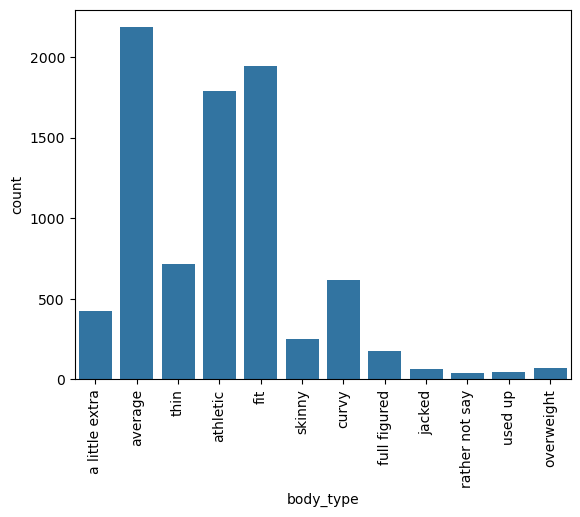

In [22]:
sns.countplot(x=df["body_type"])
plt.xticks(rotation=90);

In [23]:
df["diet"].value_counts()

diet
mostly anything        2577
anything               1030
strictly anything       822
mostly vegetarian       551
mostly other            152
strictly vegetarian     131
vegetarian              106
strictly other           62
mostly vegan             52
other                    51
strictly vegan           40
vegan                    28
mostly halal             12
mostly kosher            12
strictly halal            4
strictly kosher           2
kosher                    2
halal                     1
Name: count, dtype: int64

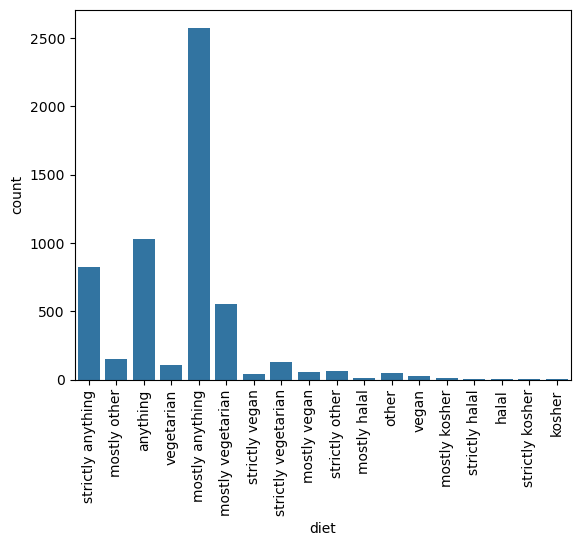

In [24]:
sns.countplot(x=df["diet"])
plt.xticks(rotation=90);

In [25]:
df["education"].value_counts()

education
graduated from college/university    3663
graduated from masters program       1359
working on college/university         941
working on masters program            241
graduated from two-year college       238
graduated from high school            202
graduated from ph.d program           200
graduated from law school             174
working on ph.d program               156
working on two-year college           153
dropped out of college/university     146
college/university                    125
graduated from space camp             102
dropped out of space camp              86
graduated from med school              73
working on space camp                  72
working on law school                  53
two-year college                       38
working on med school                  38
dropped out of two-year college        33
dropped out of ph.d program            19
masters program                        19
working on high school                 19
dropped out of masters p

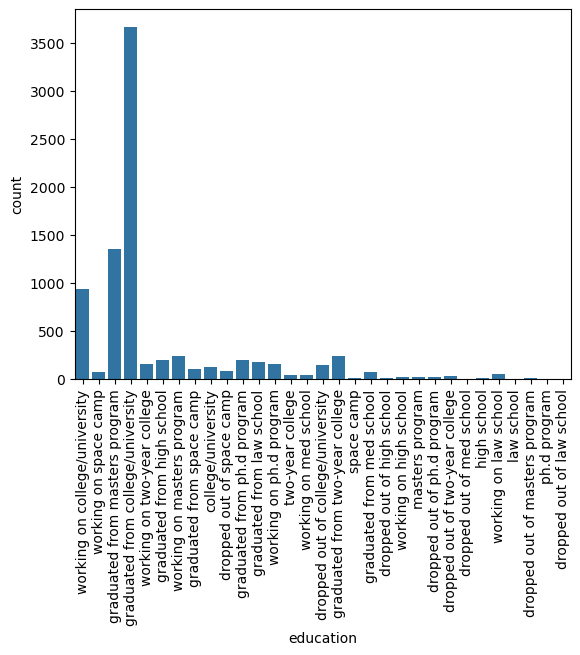

In [26]:
sns.countplot(x=df["education"])
plt.xticks(rotation=90);

In [27]:
df["orientation"].value_counts()

orientation
straight    7772
gay          859
bisexual     413
Name: count, dtype: int64

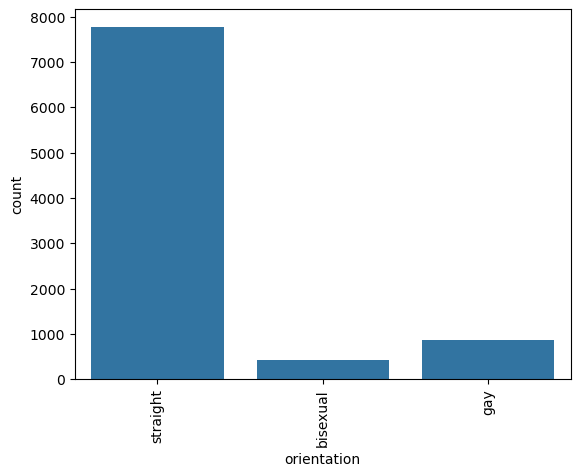

In [28]:
sns.countplot(x=df["orientation"])
plt.xticks(rotation=90);

In [29]:
df["status"].value_counts()

status
single            8461
seeing someone     282
available          259
married             42
Name: count, dtype: int64

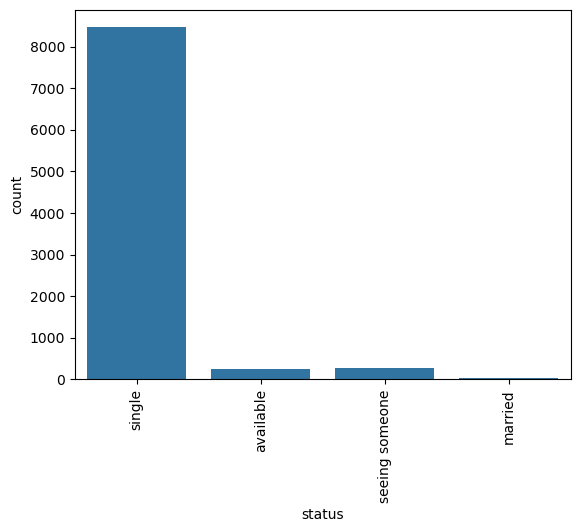

In [30]:
sns.countplot(x=df["status"])
plt.xticks(rotation=90);

<Axes: xlabel='sex', ylabel='count'>

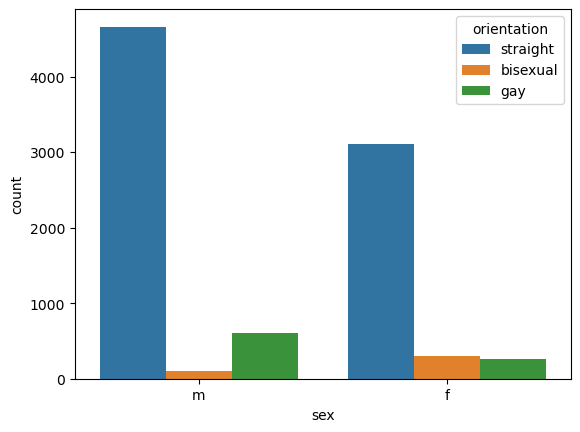

In [31]:
sns.countplot(x=df['sex'], hue=df['orientation'])

<Axes: xlabel='sex', ylabel='count'>

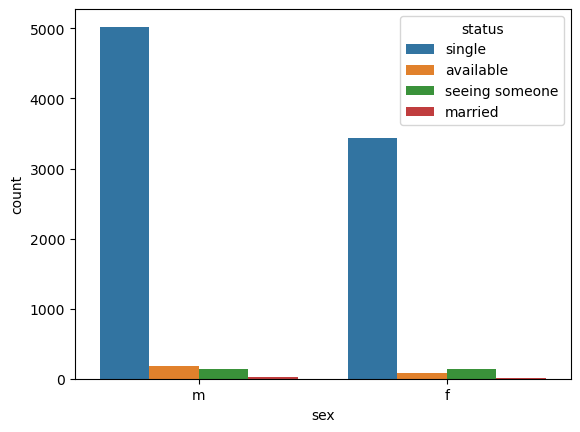

In [32]:
sns.countplot(x=df['sex'], hue=df['status'])

<Axes: xlabel='body_type', ylabel='count'>

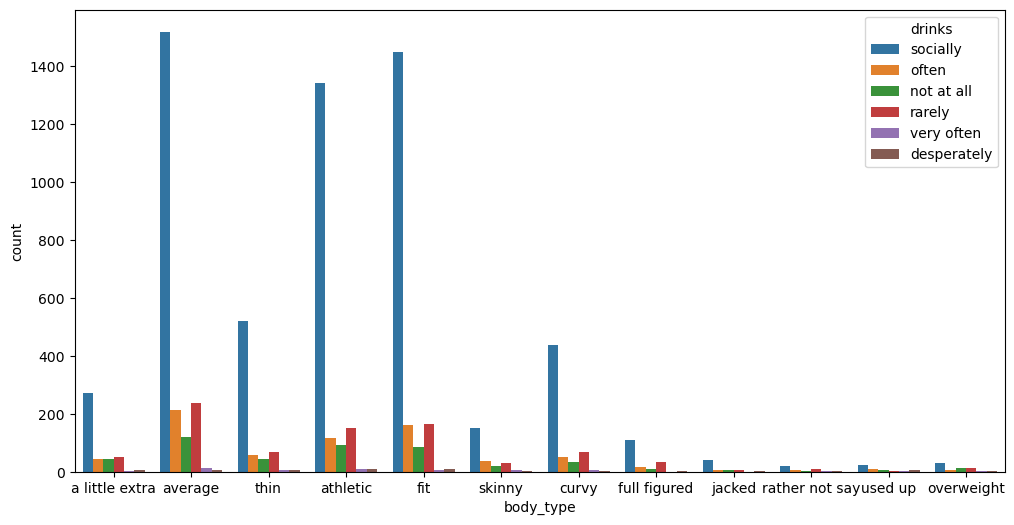

In [33]:
plt.figure(figsize=(12,6))
sns.countplot(x=df['body_type'], hue=df['drinks'])

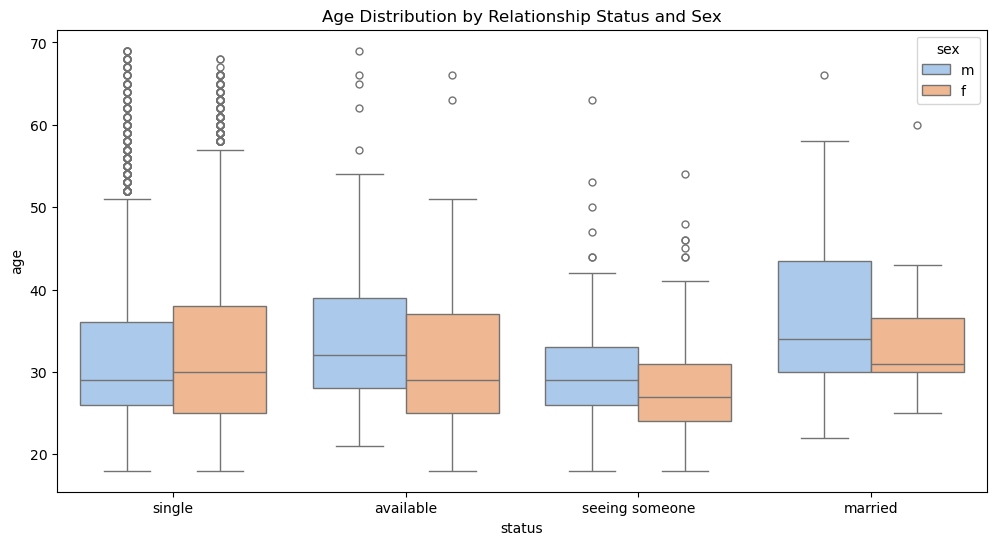

In [34]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="status", y="age", hue="sex", palette="pastel", fliersize=5)
plt.title("Age Distribution by Relationship Status and Sex")
plt.show()


<Axes: xlabel='sex', ylabel='income'>

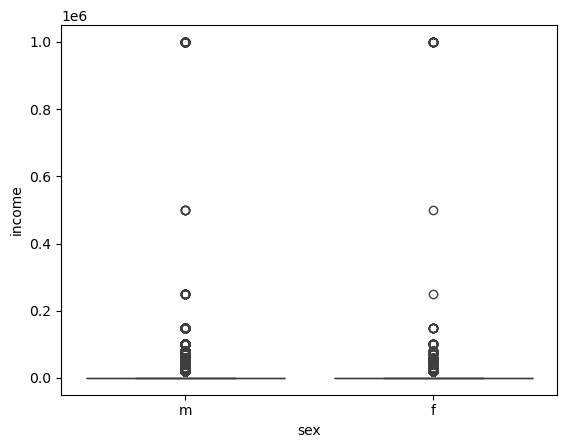

In [35]:
sns.boxplot(x="sex", y="income", data=df)

In [36]:
# inç i cm çeviriyoruz
df["height"] = df["height"] * 2.54

<Axes: xlabel='sex', ylabel='height'>

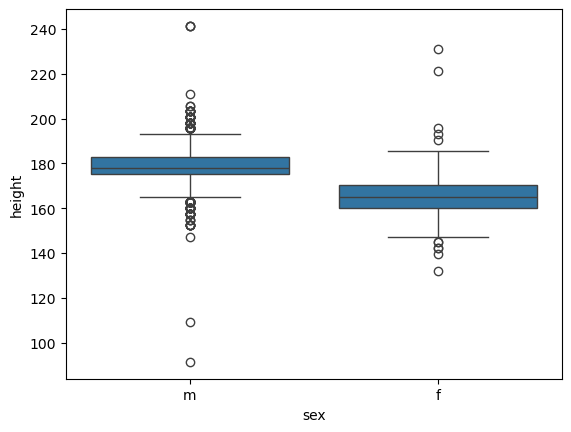

In [37]:
sns.boxplot(x="sex", y="height", data=df)

In [38]:
outliers = df.quantile(q=.995, numeric_only=True)

In [39]:
df=df[(df["income"] < outliers["income"])]

In [40]:
#df=df[(df["height"] < outliers["height"])]

In [41]:
Q1 = df["height"].quantile(0.25)
Q3 = df["height"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Aykırı değerleri sınıra çekiyoruz
df["height"] = df["height"].clip(lower=lower_bound, upper=upper_bound)


<Axes: xlabel='age', ylabel='height'>

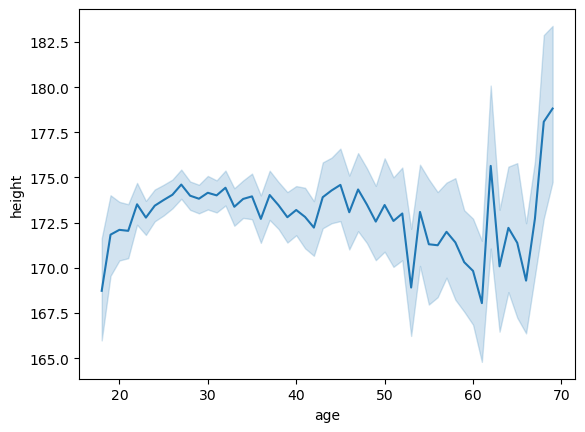

In [42]:
sns.lineplot(x="age", y="height", data=df)

In [43]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,8972.00,32.15,9.44,18.00,25.00,30.00,37.00,69.00
height,8972.00,173.50,9.75,148.59,167.64,172.72,180.34,199.39
income,8972.00,11713.41,32366.97,-1.00,-1.00,-1.00,-1.00,500000.00


In [44]:
df["location"].value_counts("location")

location
san francisco, california   0.51
oakland, california         0.13
berkeley, california        0.08
san mateo, california       0.02
palo alto, california       0.02
                            ... 
freedom, california         0.00
boulder, colorado           0.00
san geronimo, california    0.00
petaluma, california        0.00
madrid, spain               0.00
Name: proportion, Length: 86, dtype: float64

In [45]:
df[["city", "state"]] = df["location"].str.split(", ", expand=True)

In [46]:
df.drop("location", axis=1, inplace=True)

In [47]:
df.sample(2)

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9,ethnicity,height,income,job,last_online,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status,city,state
7462,31.00,fit,NaN,often,NaN,graduated from college/university,"born in east africa (tanzania), reborn in the ...",working in the search industry.<br />\n<br />\...,"things that don't matter: bar games (foosball,...",my curly hair - i've gotten a lot of complimen...,"music: queens of the stone age, alice in chain...","electricity, my guitar, food+shelter+clothing,...",NaN,combining activities with happy hour (e.g. hh ...,NaN,nice and not a debbie-downer. pwa pwa pwaaaaa,other,182.88,-1.00,computer / hardware / software,2012-01-06-02-15,NaN,straight,NaN,agnosticism and laughing about it,m,cancer but it doesn&rsquo;t matter,when drinking,"english (fluently), swahili (fluently), hindi ...",single,san francisco,california
411,41.00,thin,mostly anything,socially,never,graduated from college/university,i have a love for good food and drinks. red wi...,the last 10 years i have specialized in a fiel...,photography is an interest of mine which gives...,my eyes....,"princess diary, the godfather, shawshank redem...","affection, information, my powder room, a hot ...",philosophy of life.,"i love to lounge around, taking it easy on col...",i prefer to not talk about religion or politic...,after going through the process of setting up ...,"native american, white",162.56,-1.00,clerical / administrative,2012-04-04-15-13,"has kids, but doesn&rsquo;t want more",straight,likes dogs and dislikes cats,catholicism but not too serious about it,f,taurus but it doesn&rsquo;t matter,no,english (fluently),single,vallejo,california


In [48]:
df["offspring"].value_counts("offspring")

offspring
doesn&rsquo;t have kids                               0.31
doesn&rsquo;t have kids, but might want them          0.16
doesn&rsquo;t have kids, but wants them               0.15
doesn&rsquo;t want kids                               0.12
has a kid                                             0.08
has kids                                              0.07
doesn&rsquo;t have kids, and doesn&rsquo;t want any   0.04
has kids, but doesn&rsquo;t want more                 0.02
has a kid, but doesn&rsquo;t want more                0.01
has a kid, and might want more                        0.01
might want kids                                       0.01
wants kids                                            0.01
has kids, and might want more                         0.01
has a kid, and wants more                             0.00
has kids, and wants more                              0.00
Name: proportion, dtype: float64

In [49]:
df["offspring"] = df["offspring"].str.replace("&rsquo;", "'", regex=False) # html karakterlerini temizleme

In [50]:
df["has_kids"] = df["offspring"].str.contains("has|a kid", na=False).astype(int) # çocuk var mı 1 0

In [51]:
# Çocuk istiyor mu
def parse_wants_kids(text):
    if isinstance(text, str):
        if "doesn't want" in text:
            return "no"
        elif "might want" in text:
            return "maybe"
        elif "wants" in text:
            return "yes"
        else:
            return "unknown"
    else:
        return "no"

df["wants_kids"] = df["offspring"].apply(parse_wants_kids)

In [52]:
df.drop("offspring", axis=1, inplace=True)

In [53]:
df.sample(2)

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9,ethnicity,height,income,job,last_online,orientation,pets,religion,sex,sign,smokes,speaks,status,city,state,has_kids,wants_kids
388,32.00,average,NaN,socially,never,graduated from college/university,"easy going, fun, good sense of humor...",heading towards my dream at the same time havi...,things i want to do...,my face... and wonder what i am...,don't really read books.. behind enemy lines.....,iphone<br />\nsleep<br />\nsportbikes<br />\nj...,of how to make tomorrow better than yesterday ...,working..,joining this app... i'm a first timer on this ...,you want.. ;),"asian, pacific islander",172.72,-1.00,NaN,2012-02-10-16-30,straight,NaN,christianity but not too serious about it,m,leo,when drinking,english,single,daly city,california,0,no
5498,39.00,fit,NaN,socially,NaN,graduated from masters program,i live in temescal but do not own a pair of sk...,working and playing with people with autism by...,breathing. at least so far.,i'm white. then the knees.,"books...hesse, vonnegut, salinger, steinbeck, ...",friends &amp; family<br />\nbeats<br />\nbaske...,who? what? where? when? why? and how?,NaN,i am certifiably sane.,you want to or you want to smile or you need t...,white,170.18,-1.00,other,2012-06-29-17-51,straight,likes dogs and has cats,NaN,m,sagittarius but it doesn&rsquo;t matter,no,english (okay),single,oakland,california,0,no


In [54]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0',
       'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7',
       'essay8', 'essay9', 'ethnicity', 'height', 'income', 'job',
       'last_online', 'orientation', 'pets', 'religion', 'sex', 'sign',
       'smokes', 'speaks', 'status', 'city', 'state', 'has_kids',
       'wants_kids'],
      dtype='object')>

In [55]:
df["pets"].value_counts("pets")

pets
likes dogs and likes cats         0.37
likes dogs                        0.18
likes dogs and has cats           0.11
has dogs                          0.11
has dogs and likes cats           0.06
likes dogs and dislikes cats      0.05
has dogs and has cats             0.04
has cats                          0.03
likes cats                        0.03
has dogs and dislikes cats        0.01
dislikes dogs and dislikes cats   0.01
dislikes dogs and likes cats      0.01
dislikes cats                     0.00
dislikes dogs and has cats        0.00
dislikes dogs                     0.00
Name: proportion, dtype: float64

In [56]:
# Köpekler ve kediler için statü belirleyici fonksiyon
def parse_pet_status(text, animal):
    if pd.isna(text):
        return "dislikes"
    if f"dislikes {animal}" in text:
        return "dislikes"
    elif f"has {animal}" in text:
        return "has"
    elif f"likes {animal}" in text:
        return "likes"
    else:
        return "dislikes"

# Yeni sütunları oluştur
df["dog_status"] = df["pets"].apply(lambda x: parse_pet_status(x, "dogs"))
df["cat_status"] = df["pets"].apply(lambda x: parse_pet_status(x, "cats"))

In [57]:
df.drop("pets", axis=1, inplace=True)

In [58]:
df.sample(3)

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9,ethnicity,height,income,job,last_online,orientation,religion,sex,sign,smokes,speaks,status,city,state,has_kids,wants_kids,dog_status,cat_status
2774,26.00,a little extra,strictly anything,rarely,never,space camp,by the 26 years old 6 foot 1 wife blue eyes i ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,white,185.42,20000.00,retired,2012-06-17-15-32,straight,christianity,m,scorpio,no,english,single,san francisco,california,0,yes,has,dislikes
3657,22.00,fit,mostly anything,socially,never,working on two-year college,i am a motorcycle enthusiast. who is looking t...,"at this moment life is for the living, and tha...","music, making beats and making the right girl ...",my sense of humor.,"- sons of anarchy<br />\n-r&amp;b, rap, hip-ho...","1. food, 2. computer, 3. music, 4. cell phone,...","i reflect a lot on life, where i'm going and w...","like i said...living life to the fullest, beca...",i am not going to give all of myself away all ...,"you would like to laugh, have a good time and ...",black,182.88,-1.00,law / legal services,2012-06-29-22-08,straight,NaN,m,scorpio and it&rsquo;s fun to think about,no,english,single,san francisco,california,0,no,dislikes,dislikes
8859,38.00,average,strictly anything,socially,never,graduated from space camp,now accepting applications for minions and par...,planning to take over the world,i'll be the devil on your shoulder if you foll...,since of humor,"anne rice, stephen king, horror, rock and mexican",airbrushing<br />\nmusic<br />\nlaptop<br />\n...,what i'm going to paint next,reeking havoc,my rice crispies talk to me.. no need to be je...,"your serious about meeting, can laugh at a goo...","native american, white",187.96,-1.00,artistic / musical / writer,2012-06-24-11-02,straight,NaN,m,leo but it doesn&rsquo;t matter,trying to quit,english (fluently),single,oakland,california,1,unknown,has,has


In [59]:
df["religion"].value_counts("religion")

religion
agnosticism                                  0.07
other                                        0.07
agnosticism but not too serious about it     0.06
agnosticism and laughing about it            0.06
catholicism but not too serious about it     0.06
atheism                                      0.06
atheism and laughing about it                0.05
other and laughing about it                  0.05
christianity but not too serious about it    0.05
christianity                                 0.05
other but not too serious about it           0.04
judaism but not too serious about it         0.04
atheism but not too serious about it         0.03
catholicism                                  0.03
atheism and somewhat serious about it        0.02
christianity and somewhat serious about it   0.02
other and somewhat serious about it          0.02
catholicism and laughing about it            0.02
judaism and laughing about it                0.02
agnosticism and somewhat serious about it

In [60]:
import re

def extract_religion(text):
    if pd.isna(text):
        return "unspecified"
    return text.split(" ")[0]  # ilk kelime: din adı

def extract_seriousness(text):
    if pd.isna(text):
        return "unspecified"
    text = text.lower()
    if "not too serious" in text:
        return "not serious"
    elif "somewhat serious" in text:
        return "somewhat serious"
    elif "very serious" in text:
        return "very serious"
    elif "laughing" in text:
        return "laughing"
    else:
        return "unspecified"

df["religion_type"] = df["religion"].apply(extract_religion)
df["religion_seriousness"] = df["religion"].apply(extract_seriousness)

In [61]:
df.sample(4)

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9,ethnicity,height,income,job,last_online,orientation,religion,sex,sign,smokes,speaks,status,city,state,has_kids,wants_kids,dog_status,cat_status,religion_type,religion_seriousness
5091,41.00,average,mostly anything,socially,never,graduated from college/university,"i was born and raised in lima, peru and i move...",i am committed to a good life balance... i am ...,"sharing my beliefs through teaching, participa...","my smile, friendliness... after a few minutes ...",books:<br />\nthe house of spirits/ la casa de...,family<br />\nfriends<br />\npassport<br />\nm...,NaN,"is there such a thing? anyways, usually on a f...",NaN,you are happy with your life.<br />\nyou are h...,hispanic / latin,160.02,-1.00,banking / financial / real estate,2012-06-25-19-28,straight,catholicism,f,aries,no,"english, spanish",single,san leandro,california,0,no,likes,has,catholicism,unspecified
5863,31.00,average,NaN,socially,never,graduated from college/university,"laid-back, professional, inquisitive, hand-dru...",i work for a great company and i will be promo...,sales and playing percussive instruments! i lo...,people comment on my hair and smile...otherwis...,this is a tough one because there is too many ...,no particular order ...<br />\n<br />\naffecti...,my kitties<br />\nmy job<br />\nmoney<br />\nf...,in the house cooking and watching a movie or h...,i am afraid of crazy people that online date! ...,you are not crazy.<br />\nyou like to chill.<b...,"black, native american, other",172.72,-1.00,executive / management,2012-06-14-14-00,gay,NaN,f,scorpio and it&rsquo;s fun to think about,NaN,"english (fluently), spanish (okay)",single,oakland,california,0,no,likes,has,unspecified,unspecified
4228,26.00,average,NaN,socially,never,working on college/university,for the longest time i didn't want to write my...,"currently i am enjoying the city life, working...","ignoring the bad and focusing on the good, eve...",apparently my extra lushous hair. strangers se...,books:<br />\nsword of truth series<br />\nthe...,"my eyes, without them i could not feast on the...",NaN,"eating pizza, drinking root beer, and playing ...",NaN,"you're obsessed with art and entertainment, th...",white,182.88,-1.00,artistic / musical / writer,2012-06-29-20-26,straight,catholicism but not too serious about it,m,leo but it doesn&rsquo;t matter,no,"english (fluently), italian (okay)",seeing someone,alameda,california,0,no,likes,likes,catholicism,not serious
2176,33.00,athletic,mostly anything,not at all,never,graduated from college/university,"i work, a lot. and, i'm working on it. that be...",i seem to be in a phase where i spend a lot of...,NaN,"you'd have to ask peeps. errrm, i'm a white boy.","all-time favorite movie: <a class=""ilink"" href...","or, the six things in my life i'd rather never...","work. again, i'm working on that.<br />\n<br /...",with friends.,NaN,NaN,white,172.72,-1.00,other,2012-06-20-07-39,gay,other and very serious about it,m,virgo and it&rsquo;s fun to think about,no,"english (fluently), german (fluently)",single,san francisco,california,0,no,likes,dislikes,other,very serious


In [62]:
df.drop("religion", axis=1, inplace=True)

In [63]:
df["sign"].value_counts("sign")

sign
taurus and it&rsquo;s fun to think about        0.04
leo and it&rsquo;s fun to think about           0.04
gemini and it&rsquo;s fun to think about        0.04
virgo and it&rsquo;s fun to think about         0.03
libra and it&rsquo;s fun to think about         0.03
pisces and it&rsquo;s fun to think about        0.03
cancer and it&rsquo;s fun to think about        0.03
scorpio and it&rsquo;s fun to think about       0.03
aquarius but it doesn&rsquo;t matter            0.03
aries but it doesn&rsquo;t matter               0.03
aries and it&rsquo;s fun to think about         0.03
sagittarius and it&rsquo;s fun to think about   0.03
leo but it doesn&rsquo;t matter                 0.03
virgo but it doesn&rsquo;t matter               0.03
cancer but it doesn&rsquo;t matter              0.03
gemini but it doesn&rsquo;t matter              0.03
aquarius and it&rsquo;s fun to think about      0.03
taurus but it doesn&rsquo;t matter              0.03
sagittarius but it doesn&rsquo;t matter  

In [64]:
# HTML düzeltmesi
df["sign"] = df["sign"].str.replace("&rsquo;", "'", regex=False)

In [65]:
# Burç adını çıkar
def extract_zodiac(text):
    if pd.isna(text):
        return "unspecified"
    return text.split(" ")[0].strip().lower()

# Önem derecesini çıkar
def extract_importance(text):
    if pd.isna(text):
        return "unspecified"
    text = text.lower()
    if "fun to think about" in text:
        return "fun"
    elif "doesn't matter" in text:
        return "not matter"
    elif "matters a lot" in text:
        return "matters a lot"
    else:
        return "doesn't matter"

df["zodiac_sign"] = df["sign"].apply(extract_zodiac)
df["sign_importance"] = df["sign"].apply(extract_importance)

In [66]:
df.drop("sign", axis=1, inplace=True)

In [67]:
df.sample(4)

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9,ethnicity,height,income,job,last_online,orientation,sex,smokes,speaks,status,city,state,has_kids,wants_kids,dog_status,cat_status,religion_type,religion_seriousness,zodiac_sign,sign_importance
8360,43.00,curvy,strictly anything,socially,sometimes,graduated from college/university,i have been living in san francisco since 2003...,trying to decide my next move. been traveling ...,getting people to open up to me. befriending d...,i have an opinion,i have always been a tom robbins fan. i am a c...,"great sleep, trees, food with friends, snow, s...",what to do on the weekends.,"meeting someone, somewhere, for something.",i try to remember to say thank you for everyda...,you have a passport and love cheap indian food.,white,165.10,-1.00,rather not say,2012-06-27-02-36,bisexual,f,no,"english (fluently), spanish (okay)",single,san francisco,california,0,no,likes,likes,agnosticism,not serious,gemini,fun
4285,22.00,fit,strictly vegan,often,never,working on college/university,"i'm an artist and a thinker, a romantic and a ...",for serious... who knows,NaN,NaN,"pablo neruda, nietzsche, ee cummings",NaN,NaN,NaN,i would gaze into your eyes for as long as i c...,NaN,NaN,187.96,20000.00,student,2012-02-18-18-40,straight,m,no,"english, latin (poorly)",single,san francisco,california,0,maybe,dislikes,dislikes,other,very serious,taurus,fun
8125,32.00,average,NaN,socially,never,graduated from college/university,"i'm from the mid-west, moved here from michiga...",NaN,NaN,NaN,"i love music, especially live shows. i could t...",1. french pressed coffee and cream<br />\n2. m...,NaN,NaN,NaN,NaN,white,157.48,-1.00,medicine / health,2011-10-16-10-51,straight,f,no,english,single,oakland,california,0,no,likes,has,unspecified,unspecified,unspecified,unspecified
7314,27.00,average,anything,not at all,never,working on two-year college,"aloof type fella, hell of a guy, i love myself...",done with school and seeking work as a graphic...,"putting the toilet seat down, since it's clear...",is my dark sense of humor. if my personality t...,"books: bret easton ellis, charles bukowski, ma...","music, animation, nostalgia, dark humor, creat...",why don't women ever put the toilet seat up? h...,"rolling three heads deep with me, myself, and ...","i'm not an asshole. hard to believe, right? i ...",- you've made it this far without dismissing m...,hispanic / latin,170.18,-1.00,NaN,2012-06-30-04-13,straight,m,no,english,single,san francisco,california,0,unknown,dislikes,dislikes,agnosticism,unspecified,capricorn,fun


In [68]:
print(" Drinks column value counts:")
print(df["drinks"].value_counts(dropna=False), "\n")

print(" Drugs column value counts:")
print(df["drugs"].value_counts(dropna=False), "\n")

print(" Smokes column value counts:")
print(df["smokes"].value_counts(dropna=False))

 Drinks column value counts:
drinks
socially       6385
rarely          878
often           770
not at all      494
NaN             348
very often       50
desperately      47
Name: count, dtype: int64 

 Drugs column value counts:
drugs
never        5674
NaN          2111
sometimes    1130
often          57
Name: count, dtype: int64 

 Smokes column value counts:
smokes
no                6753
NaN                721
sometimes          532
when drinking      461
yes                284
trying to quit     221
Name: count, dtype: int64


In [69]:
df['drinks'].fillna('socially', inplace=True)
df['drugs'].fillna('never', inplace=True)
df['smokes'].fillna('no', inplace=True)

In [70]:
print(" Drinks column value counts:")
print(df["drinks"].value_counts(dropna=False), "\n")

print(" Drugs column value counts:")
print(df["drugs"].value_counts(dropna=False), "\n")

print(" Smokes column value counts:")
print(df["smokes"].value_counts(dropna=False))

 Drinks column value counts:
drinks
socially       6733
rarely          878
often           770
not at all      494
very often       50
desperately      47
Name: count, dtype: int64 

 Drugs column value counts:
drugs
never        7785
sometimes    1130
often          57
Name: count, dtype: int64 

 Smokes column value counts:
smokes
no                7474
sometimes          532
when drinking      461
yes                284
trying to quit     221
Name: count, dtype: int64


In [71]:
drink_map = {
    "not at all": 0,
    "rarely": 1,
    "socially": 2,
    "often": 3,
    "very often": 4,
    "desperately": 5
}

df["drinks_encoded"] = df["drinks"].map(drink_map)

In [72]:
drug_map = {
    "never": 0,
    "sometimes": 1,
    "often": 2
}

df["drugs_encoded"] = df["drugs"].map(drug_map)

In [73]:
smoke_map = {
    "no": 0,
    "trying to quit": 1,
    "sometimes": 2,
    "when drinking": 3,
    "yes": 4
}

df["smokes_encoded"] = df["smokes"].map(smoke_map)

In [74]:
df.drop(columns=["drinks", "drugs", "smokes"], inplace=True)

In [75]:
df.sample(3)

,age,body_type,diet,education,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9,ethnicity,height,income,job,last_online,orientation,sex,speaks,status,city,state,has_kids,wants_kids,dog_status,cat_status,religion_type,religion_seriousness,zodiac_sign,sign_importance,drinks_encoded,drugs_encoded,smokes_encoded
4497,40.00,a little extra,anything,graduated from masters program,i'm not too fond with writing these things i'd...,what am i doing with my life? i work. i hang o...,"organizing events, playing with electronics, b...",my laugh and smile,there are too many fav on my list but we can t...,"my cellphone, water bottle, my friends and fam...",what i want to do in the next 6 months and whe...,hanging out with friends or spending a quiet n...,NaN,you want to know more.... happy searching!,"asian, pacific islander",157.48,-1.00,education / academia,2012-06-29-09-55,straight,f,english,single,san francisco,california,0,no,dislikes,dislikes,catholicism,unspecified,libra,doesn't matter,2,0,0
4482,29.00,average,NaN,NaN,welcome and nice to meet you. i am kinda hard ...,i'm having fun with my life and having fun doi...,"i'm good at a lot of things, kinda jack of all...",i'm shy and don't really talk. but i sure list...,i love mexican food.<br />\ni am big fan of ma...,my friends &amp; family<br />\nmy wife<br />\n...,i think about everything from creationism to w...,hanging out or relaxing with family or friends.,"lol, what you wanna know? i'm pretty open abou...","you should just message me, i'm pretty cool gu...",white,180.34,-1.00,transportation,2011-09-17-20-34,straight,m,"english (fluently), tagalog (poorly)",married,walnut creek,california,0,no,has,dislikes,catholicism,somewhat serious,capricorn,fun,1,0,0
7041,25.00,thin,NaN,graduated from college/university,"i'm new to sf, outgoing, audacious, fun, and l...",i'm figuring it out each day...,baking cookies and making a mess in the proces...,my laugh...,fave books: anna karenina &amp; sylvia plath f...,coffee<br />\nfamily<br />\nheels<br />\nvogue...,what's for dinner...,NaN,NaN,"your nice, honest &amp; have a pretty awesome ...",NaN,170.18,-1.00,NaN,2012-01-29-17-43,straight,f,english,single,san mateo,california,0,no,dislikes,dislikes,unspecified,unspecified,libra,doesn't matter,2,0,0


In [76]:
df.drop("speaks", axis=1, inplace=True)

In [77]:
df['text'] = df['essay0'].astype(str) + ' ' + df['essay1'] + ' ' + df['essay2']+ ' ' + df['essay3']+ ' ' +df['essay4']+ ' ' + df['essay5']+ ' ' + df['essay6']+ ' ' + df['essay7']+ ' ' + df['essay8']+ ' ' + df['essay9']
df.drop(columns=['essay0', 'essay1', 'essay2', "essay3", "essay4","essay5","essay6","essay7","essay8","essay9"], inplace=True)

In [78]:
df.sample(3)

,age,body_type,diet,education,ethnicity,height,income,job,last_online,orientation,sex,status,city,state,has_kids,wants_kids,dog_status,cat_status,religion_type,religion_seriousness,zodiac_sign,sign_importance,drinks_encoded,drugs_encoded,smokes_encoded,text
2125,43.00,a little extra,NaN,graduated from college/university,asian,157.48,50000.00,medicine / health,2012-06-21-22-18,straight,f,single,oakland,california,0,no,dislikes,has,agnosticism,laughing,gemini,not matter,2,0,0,NaN
795,31.00,athletic,mostly anything,graduated from college/university,white,185.42,-1.00,medicine / health,2012-06-30-00-41,straight,m,single,petaluma,california,0,no,likes,dislikes,christianity,unspecified,virgo,doesn't matter,2,0,0,NaN
1089,45.00,a little extra,mostly anything,graduated from college/university,asian,172.72,-1.00,other,2011-12-17-23-52,straight,m,single,berkeley,california,1,unknown,dislikes,dislikes,other,unspecified,unspecified,unspecified,0,0,0,"entrepreneur, mostly in tech, but now looking ..."


In [79]:
df["text"]= df["text"].str.lower() #kucuk harfe donusturduk
df["text"]= df["text"].str.replace('[^\w\s]','')#noktalama işaretlerini kaldır
df["text"]= df["text"].str.replace('\n','') # slash n leri bul kaldır boşlukları bul kaldır
df["text"]= df["text"].str.replace('\d+','') #rakamları bul kaldır
df["text"]= df["text"].str.replace('\r','') #satırbaslarını kaldır

In [80]:
#!pip install nltk

In [81]:
import nltk
nltk.download('punkt')  # Örneğin kelime/sentence tokenize için
from textblob import TextBlob

# 1. Duygu analizi fonksiyonu (1–5 arası)
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity <= -0.3:
        return 1
    elif polarity <= -.1:
        return 2
    elif polarity <= 0.1:
        return 3
    elif polarity <= 0.3:
        return 4
    else:
        return 5

# 2. Uygula: Boşsa 2 ver, değilse analiz yap
df["sentiment"] = df["text"].apply(lambda x: get_sentiment(x) if pd.notna(x) and str(x).strip() != "" else 3)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\OguzToy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [82]:
df["sentiment"].value_counts()

sentiment
3    4917
4    3588
5     451
2      14
1       2
Name: count, dtype: int64

In [83]:
df.drop("text",axis=1,inplace=True)

In [84]:
df["last_online"].value_counts()

last_online
2012-06-29-22-56    15
2012-06-29-22-58    11
2012-06-29-22-35    11
2012-06-29-22-33    11
2012-06-29-22-55    10
                    ..
2012-06-21-11-37     1
2012-06-27-18-13     1
2012-06-29-02-42     1
2012-06-27-17-51     1
2012-06-14-15-14     1
Name: count, Length: 6356, dtype: int64

In [85]:
# Son girişten 2012-07-01 e kaç gün geçtiğini hesaplıyoruz

# last_online sütununu datetime'a çevir
df["last_online_dt"] = pd.to_datetime(df["last_online"], format="%Y-%m-%d-%H-%M", errors="coerce")

# Referans tarihi tanımla
reference_date = pd.to_datetime("2012-07-01")

# Gün farkını hesapla
df["days_since_last_online"] = (reference_date - df["last_online_dt"]).dt.days


In [86]:
df.drop(columns=["last_online","last_online_dt"], inplace=True)

In [87]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['age', 'body_type', 'diet', 'education', 'ethnicity', 'height',
       'income', 'job', 'orientation', 'sex', 'status', 'city', 'state',
       'has_kids', 'wants_kids', 'dog_status', 'cat_status', 'religion_type',
       'religion_seriousness', 'zodiac_sign', 'sign_importance',
       'drinks_encoded', 'drugs_encoded', 'smokes_encoded', 'sentiment',
       'days_since_last_online'],
      dtype='object')>

In [88]:
df["education"].value_counts()

education
graduated from college/university    3634
graduated from masters program       1358
working on college/university         933
working on masters program            240
graduated from two-year college       238
graduated from high school            202
graduated from ph.d program           196
graduated from law school             174
working on ph.d program               156
working on two-year college           152
dropped out of college/university     145
college/university                    124
graduated from space camp              95
dropped out of space camp              81
graduated from med school              72
working on space camp                  68
working on law school                  51
working on med school                  38
two-year college                       38
dropped out of two-year college        32
working on high school                 19
dropped out of ph.d program            18
masters program                        18
dropped out of masters p

In [89]:
# Eğitim seviyesi ve durumunu belirleme
def extract_edu_level(text):
    if pd.isna(text):
        return "unspecified"
    text = text.lower()
    if "high school" in text:
        return "high school"
    elif "two-year college" in text:
        return "college"
    elif "college/university" in text:
        return "college"
    elif "masters" in text:
        return "masters"
    elif "ph.d" in text:
        return "phd"
    elif "law school" in text:
        return "law"
    elif "med school" in text:
        return "med"
    elif "space camp" in text:
        return "other"
    else:
        return "unspecified"

def extract_edu_status(text):
    if pd.isna(text):
        return "unspecified"
    text = text.lower()
    if "graduated from" in text:
        return "graduated"
    elif "working on" in text:
        return "working on"
    elif "dropped out of" in text:
        return "dropped out"
    else:
        return "unspecified"

In [90]:
df["education_level"] = df["education"].apply(extract_edu_level)
df["education_status"] = df["education"].apply(extract_edu_status)

In [91]:
df.drop("education",axis=1,inplace=True)

In [92]:
df.head(2)

,age,body_type,diet,ethnicity,height,income,job,orientation,sex,status,city,state,has_kids,wants_kids,dog_status,cat_status,religion_type,religion_seriousness,zodiac_sign,sign_importance,drinks_encoded,drugs_encoded,smokes_encoded,sentiment,days_since_last_online,education_level,education_status
0,22.00,a little extra,strictly anything,"asian, white",190.50,-1.00,transportation,straight,m,single,south san francisco,california,0,maybe,likes,likes,agnosticism,very serious,gemini,doesn't matter,2,0,2,3,2,college,working on
1,35.00,average,mostly other,white,177.80,80000.00,hospitality / travel,straight,m,single,oakland,california,0,maybe,likes,likes,agnosticism,not serious,cancer,doesn't matter,3,1,0,3,1,other,working on


In [93]:
df["ethnicity"].value_counts()

ethnicity
white                                             5084
asian                                              820
hispanic / latin                                   403
black                                              310
other                                              295
                                                  ... 
asian, middle eastern, black                         1
asian, middle eastern, indian                        1
asian, middle eastern, white                         1
indian, white, other                                 1
middle eastern, hispanic / latin, white, other       1
Name: count, Length: 108, dtype: int64

In [94]:
df.drop("ethnicity",axis=1,inplace=True)

In [95]:
df.sample(2)

,age,body_type,diet,height,income,job,orientation,sex,status,city,state,has_kids,wants_kids,dog_status,cat_status,religion_type,religion_seriousness,zodiac_sign,sign_importance,drinks_encoded,drugs_encoded,smokes_encoded,sentiment,days_since_last_online,education_level,education_status
58,22.00,fit,NaN,177.80,-1.00,student,straight,m,single,san francisco,california,0,no,has,has,agnosticism,unspecified,pisces,doesn't matter,2,1,2,3,261,college,working on
904,27.00,average,strictly anything,185.42,-1.00,education / academia,straight,m,single,stanford,california,0,unknown,likes,dislikes,catholicism,unspecified,unspecified,unspecified,2,0,0,4,2,phd,working on


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8972 entries, 0 to 9513
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     8972 non-null   float64
 1   body_type               8237 non-null   object 
 2   diet                    5584 non-null   object 
 3   height                  8972 non-null   float64
 4   income                  8972 non-null   float64
 5   job                     7919 non-null   object 
 6   orientation             8972 non-null   object 
 7   sex                     8972 non-null   object 
 8   status                  8972 non-null   object 
 9   city                    8972 non-null   object 
 10  state                   8972 non-null   object 
 11  has_kids                8972 non-null   int32  
 12  wants_kids              8972 non-null   object 
 13  dog_status              8972 non-null   object 
 14  cat_status              8972 non-null   objec

In [97]:
df["income"][df["income"]>20000].describe().T

count     1251.00
mean     76754.60
std      49619.54
min      30000.00
25%      50000.00
50%      70000.00
75%     100000.00
max     500000.00
Name: income, dtype: float64

In [98]:
#  income ≤ 0 olanları NaN yap
df["income"] = df["income"].apply(lambda x: np.nan if pd.notna(x) and x <= 0 else x)

# income aralıklarını oluştur (düşük, orta, yüksek gelir için)
income_bins = pd.cut(df["income"], bins=[0, 46000, 70000, np.inf], labels=["low", "medium", "high"])

# job sütunundaki boşlukları education_level + income aralığı ile doldur (ilk tur)
df["job"] = df["job"].fillna(
    df.groupby(["education_level", income_bins])["job"]
      .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# job hâlâ boş olanlar varsa → sadece education_level ile doldur (2. tur)
df["job"] = df["job"].fillna(
    df.groupby("education_level")["job"]
      .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# income sütunundaki boşlukları aynı job grubunun ortalamasıyla doldur 
df["income"] = df.groupby("job")["income"].transform(lambda x: x.fillna(x.mean()))

# income hâlâ boşsa → tüm veri setinin medyanı ile doldur
df["income"] = df["income"].fillna(0)

In [99]:
df["income"].describe().T

count     8972.00
mean     60160.75
std      29622.40
min      20000.00
25%      44821.43
50%      47423.58
75%      82679.74
max     500000.00
Name: income, dtype: float64

In [100]:
df.isnull().sum()

age                          0
body_type                  735
diet                      3388
height                       0
income                       0
job                          0
orientation                  0
sex                          0
status                       0
city                         0
state                        0
has_kids                     0
wants_kids                   0
dog_status                   0
cat_status                   0
religion_type                0
religion_seriousness         0
zodiac_sign                  0
sign_importance              0
drinks_encoded               0
drugs_encoded                0
smokes_encoded               0
sentiment                    0
days_since_last_online       0
education_level              0
education_status             0
dtype: int64

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8972 entries, 0 to 9513
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     8972 non-null   float64
 1   body_type               8237 non-null   object 
 2   diet                    5584 non-null   object 
 3   height                  8972 non-null   float64
 4   income                  8972 non-null   float64
 5   job                     8972 non-null   object 
 6   orientation             8972 non-null   object 
 7   sex                     8972 non-null   object 
 8   status                  8972 non-null   object 
 9   city                    8972 non-null   object 
 10  state                   8972 non-null   object 
 11  has_kids                8972 non-null   int32  
 12  wants_kids              8972 non-null   object 
 13  dog_status              8972 non-null   object 
 14  cat_status              8972 non-null   objec

In [102]:
df["diet"] = df["diet"].fillna(df["diet"].mode().iloc[0])

In [103]:
df["body_type"] = df["body_type"].fillna(df["body_type"].mode().iloc[0])

In [104]:
df.sample(7)

,age,body_type,diet,height,income,job,orientation,sex,status,city,state,has_kids,wants_kids,dog_status,cat_status,religion_type,religion_seriousness,zodiac_sign,sign_importance,drinks_encoded,drugs_encoded,smokes_encoded,sentiment,days_since_last_online,education_level,education_status
7542,26.00,curvy,mostly vegetarian,167.64,20000.00,computer / hardware / software,bisexual,f,seeing someone,oakland,california,0,no,likes,likes,atheism,laughing,libra,not matter,3,0,0,3,37,college,working on
6693,40.00,athletic,mostly anything,177.80,100000.00,political / government,straight,m,single,belmont,california,0,no,dislikes,dislikes,catholicism,unspecified,cancer,doesn't matter,2,0,0,3,1,college,graduated
8130,28.00,average,mostly anything,162.56,27610.06,student,straight,f,available,san francisco,california,0,yes,likes,dislikes,christianity,unspecified,cancer,not matter,2,0,0,3,39,college,working on
9094,22.00,curvy,mostly anything,172.72,27610.06,student,straight,f,single,daly city,california,0,no,has,dislikes,judaism,unspecified,taurus,fun,2,0,0,3,2,college,working on
3479,37.00,curvy,mostly anything,160.02,70000.00,sales / marketing / biz dev,straight,f,single,redwood city,california,0,no,likes,has,catholicism,laughing,virgo,not matter,2,0,2,3,351,college,graduated
9290,33.00,fit,anything,162.56,40000.00,hospitality / travel,straight,f,single,san francisco,california,0,no,dislikes,dislikes,catholicism,somewhat serious,gemini,doesn't matter,2,0,0,3,0,college,graduated
603,52.00,average,mostly anything,160.02,123111.11,executive / management,straight,f,single,berkeley,california,0,no,has,dislikes,catholicism,not serious,scorpio,fun,2,0,0,4,6,masters,graduated


In [105]:
# Yaşa göre kuşakları belirleyen fonksiyon
def get_generation(age):
    if 18 <= age <= 32:
        return "Millennial"
    elif 33 <= age <= 47:
        return "Gen X"
    elif 48 <= age <= 70:
        return "Boomer"
    else:
        return "Other"

# Yeni 'generation' sütununu oluştur
df['generation'] = df['age'].apply(get_generation)

In [106]:
# Kuşaklara göre kaç kişi olduğuna bakalım
generation_counts = df['generation'].value_counts()

In [107]:
df[['age', 'generation']].head(), generation_counts

(    age  generation
 0 22.00  Millennial
 1 35.00       Gen X
 2 38.00       Gen X
 3 23.00  Millennial
 4 29.00  Millennial,
 generation
 Millennial    5683
 Gen X         2575
 Boomer         714
 Name: count, dtype: int64)

In [108]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,8972.00,32.15,9.44,18.00,25.00,30.00,37.00,69.00
height,8972.00,173.50,9.75,148.59,167.64,172.72,180.34,199.39
income,8972.00,60160.75,29622.40,20000.00,44821.43,47423.58,82679.74,500000.00
has_kids,8972.00,0.08,0.28,0.00,0.00,0.00,0.00,1.00
drinks_encoded,8972.00,1.90,0.68,0.00,2.00,2.00,2.00,5.00
drugs_encoded,8972.00,0.14,0.36,0.00,0.00,0.00,0.00,2.00
smokes_encoded,8972.00,0.42,1.03,0.00,0.00,0.00,0.00,4.00
sentiment,8972.00,3.50,0.60,1.00,3.00,3.00,4.00,5.00
days_since_last_online,8972.00,36.98,74.76,0.00,1.00,3.00,25.00,369.00


In [109]:
abs(df.corr(numeric_only=True)["age"].sort_values(ascending=False))

age                      1.00
has_kids                 0.42
income                   0.17
sentiment                0.10
days_since_last_online   0.02
height                   0.03
drinks_encoded           0.11
drugs_encoded            0.12
smokes_encoded           0.15
Name: age, dtype: float64

In [110]:
x=df.drop("age", axis=1)

In [111]:
y=df["age"]

In [112]:
x=pd.get_dummies(x,drop_first=True)

In [113]:
x

,height,income,has_kids,drinks_encoded,drugs_encoded,smokes_encoded,sentiment,days_since_last_online,body_type_athletic,body_type_average,body_type_curvy,body_type_fit,body_type_full figured,body_type_jacked,body_type_overweight,body_type_rather not say,body_type_skinny,body_type_thin,body_type_used up,diet_halal,diet_kosher,diet_mostly anything,diet_mostly halal,diet_mostly kosher,diet_mostly other,diet_mostly vegan,diet_mostly vegetarian,diet_other,diet_strictly anything,diet_strictly halal,diet_strictly kosher,diet_strictly other,diet_strictly vegan,diet_strictly vegetarian,diet_vegan,diet_vegetarian,job_banking / financial / real estate,job_clerical / administrative,job_computer / hardware / software,job_construction / craftsmanship,job_education / academia,job_entertainment / media,job_executive / management,job_hospitality / travel,job_law / legal services,job_medicine / health,job_military,job_other,job_political / government,job_rather not say,...,state_spain,state_virginia,wants_kids_no,wants_kids_unknown,wants_kids_yes,dog_status_has,dog_status_likes,cat_status_has,cat_status_likes,religion_type_atheism,religion_type_buddhism,religion_type_catholicism,religion_type_christianity,religion_type_hinduism,religion_type_islam,religion_type_judaism,religion_type_other,religion_type_unspecified,religion_seriousness_not serious,religion_seriousness_somewhat serious,religion_seriousness_unspecified,religion_seriousness_very serious,zodiac_sign_aries,zodiac_sign_cancer,zodiac_sign_capricorn,zodiac_sign_gemini,zodiac_sign_leo,zodiac_sign_libra,zodiac_sign_pisces,zodiac_sign_sagittarius,zodiac_sign_scorpio,zodiac_sign_taurus,zodiac_sign_unspecified,zodiac_sign_virgo,sign_importance_fun,sign_importance_matters a lot,sign_importance_not matter,sign_importance_unspecified,education_level_high school,education_level_law,education_level_masters,education_level_med,education_level_other,education_level_phd,education_level_unspecified,education_status_graduated,education_status_unspecified,education_status_working on,generation_Gen X,generation_Millennial
0,190.50,58571.43,0,2,0,2,3,2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
1,177.80,80000.00,0,3,1,0,3,1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False
2,172.72,44821.43,0,2,0,0,3,3,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False
3,180.34,20000.00,0,2,0,0,3,2,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

### Modelling

In [115]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

In [116]:
LR = LinearRegression()
LR.fit(x_train, y_train)
LR_pred = LR.predict(x_test)

# Performans metrikleri
lr_mse = mean_squared_error(y_test, LR_pred)
lr_r2 = r2_score(y_test, LR_pred)

print("=== Linear Regression ===")
print(f"MSE: {lr_mse:.2f}")
print(f"R^2: {lr_r2:.4f}\n")

=== Linear Regression ===
MSE: 13.14
R^2: 0.8689



In [117]:
L = Lasso(random_state=42)
L.fit(x_train, y_train)
L_pred = L.predict(x_test)

# Performans metrikleri
lasso_mse = mean_squared_error(y_test, L_pred)
lasso_r2 = r2_score(y_test, L_pred)

print("=== Lasso ===")
print(f"MSE: {lasso_mse:.2f}")
print(f"R^2: {lasso_r2:.4f}\n")

=== Lasso ===
MSE: 44.45
R^2: 0.5566



In [118]:
R = Ridge(random_state=42)
R.fit(x_train, y_train)
R_pred = R.predict(x_test)

# Performans metrikleri
R_mse = mean_squared_error(y_test, R_pred)
R_r2 = r2_score(y_test, R_pred)

print("=== Ridge ===")
print(f"MSE: {R_mse:.2f}")
print(f"R^2: {R_r2:.4f}\n")

=== Ridge ===
MSE: 13.15
R^2: 0.8689



In [119]:
EN = ElasticNet(random_state=42)
EN.fit(x_train, y_train)
EN_pred = EN.predict(x_test)

# Performans metrikleri
EN_mse = mean_squared_error(y_test, LR_pred)
EN_r2 = r2_score(y_test, EN_pred)

print("=== ElasticNet ===")
print(f"MSE: {EN_mse:.2f}")
print(f"R^2: {EN_r2:.4f}\n")

=== ElasticNet ===
MSE: 13.14
R^2: 0.3074



In [120]:
xgb = XGBRegressor(random_state=42)
xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)

# Performans metrikleri
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("=== XGBRegressor ===")
print(f"MSE: {xgb_mse:.2f}")
print(f"R^2: {xgb_r2:.4f}\n")

=== XGBRegressor ===
MSE: 13.64
R^2: 0.8640



In [121]:
GB = GradientBoostingRegressor(random_state=42)
GB.fit(x_train, y_train)
GB_pred = GB.predict(x_test)

# Performans metrikleri
GB_mse = mean_squared_error(y_test, GB_pred)
GB_r2 = r2_score(y_test, GB_pred)

print("=== Gradient Boosting ===")
print(f"MSE: {GB_mse:.2f}")
print(f"R^2: {GB_r2:.4f}\n")

=== Gradient Boosting ===
MSE: 12.67
R^2: 0.8737



In [122]:
RF = RandomForestRegressor(n_estimators=100, random_state=42)
RF.fit(x_train, y_train)
RF_pred = RF.predict(x_test)

# Performans metrikleri
RF_mse = mean_squared_error(y_test, RF_pred)
RF_r2 = r2_score(y_test, RF_pred)

print("=== Random Forest ===")
print(f"MSE: {RF_mse:.2f}")
print(f"R^2: {RF_r2:.4f}\n")

=== Random Forest ===
MSE: 12.98
R^2: 0.8705



#### Deep Learning

In [124]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

In [125]:
from sklearn.preprocessing import StandardScaler

# Veriyi ölçekle
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [126]:
pd.DataFrame(x_train_scaled).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202
0,0.45,0.89,-0.30,0.14,-0.39,-0.42,-0.84,-0.48,-0.49,-0.70,-0.27,1.93,-0.14,-0.08,-0.08,-0.06,-0.17,-0.29,-0.07,-0.01,-0.01,0.71,-0.03,-0.04,-0.13,-0.08,-0.26,-0.07,-0.31,-0.02,-0.01,-0.08,-0.07,-0.12,-0.06,-0.11,-0.19,-0.12,3.44,-0.14,-0.29,-0.20,-0.21,-0.15,-0.15,-0.27,-0.06,-0.53,-0.11,-0.08,...,-0.01,-0.01,0.73,-0.49,-0.27,-0.42,-0.97,-0.37,-0.69,-0.38,-0.18,-0.30,-0.33,-0.09,-0.05,-0.24,-0.38,-0.68,1.94,-0.29,-1.04,-0.21,-0.28,-0.28,-0.24,-0.27,-0.29,3.62,-0.27,-0.26,-0.27,-0.28,-0.44,-0.27,-0.71,-0.10,1.55,-0.44,-0.17,-0.16,-0.48,-0.11,-0.17,-0.21,3.11,-1.40,2.74,-0.48,1.57,-1.33
1,0.18,-0.43,-0.30,0.14,-0.39,-0.42,-0.84,0.69,-0.49,1.44,-0.27,-0.52,-0.14,-0.08,-0.08,-0.06,-0.17,-0.29,-0.07,-0.01,-0.01,0.71,-0.03,-0.04,-0.13,-0.08,-0.26,-0.07,-0.31,-0.02,-0.01,-0.08,-0.07,-0.12,-0.06,-0.11,-0.19,-0.12,-0.29,-0.14,-0.29,-0.20,-0.21,-0.15,-0.15,-0.27,-0.06,1.90,-0.11,-0.08,...,-0.01,-0.01,0.73,-0.49,-0.27,-0.42,-0.97,-0.37,-0.69,-0.38,-0.18,-0.30,-0.33,-0.09,-0.05,-0.24,-0.38,1.47,-0.51,-0.29,0.96,-0.21,-0.28,-0.28,-0.24,-0.27,-0.29,-0.28,-0.27,-0.26,-0.27,-0.28,2.25,-0.27,-0.71,-0.10,-0.64,2.25,-0.17,-0.16,-0.48,-0.11,-0.17,-0.21,3.11,-1.40,2.74,-0.48,-0.64,0.75
2,0.18,2.16,-0.30,-2.81,-0.39,-0.42,-0.84,1.35,-0.49,-0.70,-0.27,-0.52,-0.14,-0.08,-0.08,-0.06,-0.17,-0.29,-0.07,-0.01,-0.01,0.71,-0.03,-0.04,-0.13,-0.08,-0.26,-0.07,-0.31,-0.02,-0.01,-0.08,-0.07,-0.12,-0.06,-0.11,-0.19,-0.12,-0.29,-0.14,-0.29,-0.20,4.73,-0.15,-0.15,-0.27,-0.06,-0.53,-0.11,-0.08,...,-0.01,-0.01,0.73,-0.49,-0.27,-0.42,1.03,-0.37,1.45,-0.38,-0.18,-0.30,-0.33,-0.09,-0.05,-0.24,-0.38,1.47,-0.51,-0.29,0.96,-0.21,-0.28,3.56,-0.24,-0.27,-0.29,-0.28,-0.27,-0.26,-0.27,-0.28,-0.44,-0.27,1.42,-0.10,-0.64,-0.44,-0.17,-0.16,-0.48,-0.11,-0.17,-0.21,-0.32,0.71,-0.37,-0.48,-0.64,-1.33
3,-0.34,0.12,-0.30,0.14,-0.39,-0.42,-0.84,-0.36,-0.49,1.44,-0.27,-0.52,-0.14,-0.08,-0.08,-0.06,-0.17,-0.29,-0.07,-0.01,-0.01,0.71,-0.03,-0.04,-0.13,-0.08,-0.26,-0.07,-0.31,-0.02,-0.01,-0.08,-0.07,-0.12,-0.06,-0.11,-0.19,-0.12,-0.29,-0.14,-0.29,-0.20,-0.21,-0.15,-0.15,-0.27,-0.06,-0.53,-0.11,-0.08,...,-0.01,-0.01,0.73,-0.49,-0.27,-0.42,-0.97,-0.37,-0.69,-0.38,-0.18,-0.30,-0.33,-0.09,-0.05,4.21,-0.38,-0.68,1.94,-0.29,-1.04,-0.21,-0.28,-0.28,-0.24,3.67,-0.29,-0.28,-0.27,-0.26,-0.27,-0.28,-0.44,-0.27,-0.71,-0.10,1.55,-0.44,-0.17,-0.16,-0.48,-0.11,-0.17,-0.21,-0.32,0.71,-0.37,-0.48,-0.64,0.75
4,-1.12,-1.11,-0.30,0.14,-0.39,-0.42,0.85,-0.48,-0.49,-0.70,-0.27,1.93,-0.14,-0.08,-0.08,-0.06,-0.17,-0.29,-0.07,-0.01,-0.01,-1.40,-0.03,-0.04,-0.13,-0.08,3.87,-0.07,-0.31,-0.02,-0.01,-0.08,-0.07,-0.12,-0.06,-0.11,-0.19,-0.12,-0.29,-0.14,-0.29,-0.20,-0.21,-0.15,-0.15,-0.27,-0.06,-0.53,-0.11,-0.08,...,-0.01,-0.01,-1.38,-0.49,3.67,-0.42,-0.97,-0.37,-0.69,-0.38,-0.18,-0.30,-0.33,-0.09,-0.05,-0.24,-0.38,1.47,-0.51,-0.29,0.96,-0.21,-0.28,-0.28,4.14,-0.27,-0.29,-0.28,-0.27,-0.26,-0.27,-0.28,-0.44,-0.27,1.42,-0.10,-0.64,-0.44,-0.17,-0.16,2.10,-0.11,-0.17,-0.21,-0.32,-1.40,-0.37,2.09,1.57,-1.33


In [127]:
model = Sequential()
model.add(Dense(500, activation="relu", input_shape=(x_train.shape[1],)))
model.add(Dense(380, activation="relu"))
model.add(Dense(164, activation="relu"))
model.add(Dense(80, activation="relu"))
model.add(Dense(30, activation="relu"))
model.add(Dense(4, activation="relu"))
model.add(Dense(1))  # Çıkış katmanı

model.compile(loss="mse", optimizer="adam")

In [128]:
model.fit(x_train_scaled, y_train,
          validation_data=(x_test_scaled, y_test),
          batch_size=128,
          epochs=100,
          verbose=1)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 533.4051 - val_loss: 71.9708
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 54.2076 - val_loss: 40.3288
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 25.0602 - val_loss: 27.2897
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 16.5939 - val_loss: 21.1700
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 12.6010 - val_loss: 21.3567
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 10.6369 - val_loss: 20.8366
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 9.1311 - val_loss: 18.3327
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 8.3912 - val_loss: 18.4447
Epoch 9/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 7.8170 - val_loss: 18.3434
Epoch 10/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 6.7660 - val_loss: 18.7904
Epoch 11/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 6.5908 - val_loss: 18.7485
Epoch 12/100
57/57 ━━━━━━━━━━━━━━━

In [129]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 500)                 │         102,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 380)                 │         190,380 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 164)                 │          62,484 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 80)                  │          13,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 30)                  │           2,430 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │             124 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,111,871 (4.24 MB)

 Trainable params: 370,623 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 741,248 (2.83 MB)

In [130]:
pred = model.predict(x_test_scaled) 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [131]:
(mean_squared_error(y_test,pred))**.5

4.584423587094609

In [132]:
r2_score(y_test,pred) 

0.7903757812266803

#### Classification

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8972 entries, 0 to 9513
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     8972 non-null   float64
 1   body_type               8972 non-null   object 
 2   diet                    8972 non-null   object 
 3   height                  8972 non-null   float64
 4   income                  8972 non-null   float64
 5   job                     8972 non-null   object 
 6   orientation             8972 non-null   object 
 7   sex                     8972 non-null   object 
 8   status                  8972 non-null   object 
 9   city                    8972 non-null   object 
 10  state                   8972 non-null   object 
 11  has_kids                8972 non-null   int32  
 12  wants_kids              8972 non-null   object 
 13  dog_status              8972 non-null   object 
 14  cat_status              8972 non-null   objec

In [135]:
x=df.drop("generation", axis=1)
y=df["generation"]

In [136]:
x=pd.get_dummies(x,drop_first=True)

In [137]:
from sklearn.preprocessing import LabelEncoder

In [138]:
#label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

#train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42)


scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [139]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

x = x.astype("float32")
y = y.astype("int32")

In [140]:
model=Sequential()
model.add(Dense(120, activation="relu"))
model.add(Dense(80, activation="relu"))
model.add(Dense(64, activation="relu"))
model.add(Dense(30, activation="relu"))
model.add(Dense(20, activation="relu"))
model.add(Dense(10, activation="relu"))
num_classes = len(np.unique(y_train))
model.add(Dense(num_classes, activation="softmax"))
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [141]:
model.fit(x_train_scaled, y_train, validation_data=(x_test_scaled, y_test),epochs=250,batch_size=32, validation_split=.20, verbose=1)

Epoch 1/250
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6658 - loss: 0.7621 - val_accuracy: 0.8891 - val_loss: 0.2936
Epoch 2/250
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9259 - loss: 0.2070 - val_accuracy: 0.9298 - val_loss: 0.1933
Epoch 3/250
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9654 - loss: 0.0972 - val_accuracy: 0.9448 - val_loss: 0.1911
Epoch 4/250
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9779 - loss: 0.0590 - val_accuracy: 0.9337 - val_loss: 0.2594
Epoch 5/250
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9865 - loss: 0.0392 - val_accuracy: 0.9387 - val_loss: 0.2389
Epoch 6/250
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9886 - loss: 0.0414 - val_accuracy: 0.9526 - val_loss: 0.1873
Epoch 7/250
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9945 - loss: 0.0177 - val_accuracy: 0.9482 - val_loss: 0.2213
Epoch 8/250
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9948 - loss: 0.0146 - val_accu

In [142]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 120)                 │          24,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 80)                  │           9,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           5,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 30)                  │           1,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 20)                  │             620 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 10)                  │             210 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 3)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 126,113 (492.63 KB)

 Trainable params: 42,037 (164.21 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 84,076 (328.43 KB)